<a href="https://colab.research.google.com/github/veselm73/BP_temp/blob/main/RAG_beta_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # RAG Confidence Regression Task

 This notebook implements the workflow described for the RAG Confidence Calibration task.
 We will load the data, visualize features and labels, and perform regression experiments
 using Ridge Regression and a Custom Beta Regression model.

In [1]:
# %% [code]
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta
from scipy.special import expit # Sigmoid function
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.base.model import GenericLikelihoodModel

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# %% [code]
# Cell 2: Data Loading Helper Function
def load_data(url_10, url_100=None):
    """
    Loads the top-10 and top-100 datasets.
    If url_100 is not provided, we try to construct it from url_10.
    """
    print(f"Loading Top-10 dataset from: {url_10}")
    df_10 = pd.read_csv(url_10)

    if url_100 is None:
        # Inferring the 100 filename based on the prompt description
        url_100 = url_10.replace("_10.csv", "_100.csv")

    try:
        print(f"Loading Top-100 dataset from: {url_100}")
        df_100 = pd.read_csv(url_100)
    except Exception as e:
        print(f"Could not load Top-100 dataset automatically: {e}")
        df_100 = None

    return df_10, df_100


In [3]:
# %% [code]
# Cell 3: Load Datasets
# URLs provided in the prompt
URL_10 = "https://raw.githubusercontent.com/ADS-teamA/SUJBOT2/RAG-confidence-calibration/results/rag_confidence_training_10.csv"

# Adjusting URL to point to raw content if needed, standardizing for the example:
if "github.com" in URL_10 and "raw" not in URL_10:
    URL_10 = URL_10.replace("github.com", "raw.githubusercontent.com").replace("/blob/", "/")

df_10, df_100 = load_data(URL_10)

print("\nDataset Top-10 Head:")
display(df_10.head())

Loading Top-10 dataset from: https://raw.githubusercontent.com/ADS-teamA/SUJBOT2/RAG-confidence-calibration/results/rag_confidence_training_10.csv
Loading Top-100 dataset from: https://raw.githubusercontent.com/ADS-teamA/SUJBOT2/RAG-confidence-calibration/results/rag_confidence_training_100.csv

Dataset Top-10 Head:


,query_id,query,recall_at_top10,num_relevant_chunks,num_total_candidates,std_norm_top10,entropy_norm_top10,slope_norm_top10,top_vs_rest_ratio_top10,section_diversity_top10,query_token_len,num_top_candidates
0,0,Jaký je účel bezpečnostní zprávy reaktoru VR-1?,0.666667,3,10,0.343207,1.723734,-0.109271,4.170520,1.0,7,10
1,1,Kdo je statutárním zástupcem provozovatele rea...,1.000000,1,10,0.309056,1.914167,-0.095497,3.759120,0.9,7,10
2,2,Kde se přesně nachází pracoviště reaktoru VR-1?,1.000000,2,10,0.319575,1.811459,-0.097712,4.375348,0.8,7,10
3,3,Jaké byly hlavní milníky při výstavbě a spoušt...,0.750000,4,10,0.374117,1.838129,-0.123175,2.973891,0.9,10,10
4,4,Jaký je rozdíl mezi nádobami H01 a H02?,1.000000,4,10,0.347754,2.006503,-0.119686,2.223663,0.5,8,10


Visualizing Top-10 Data:
Identified target column: recall_at_top10


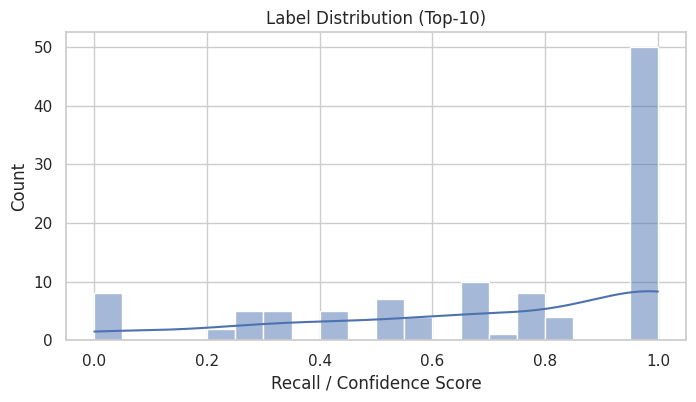

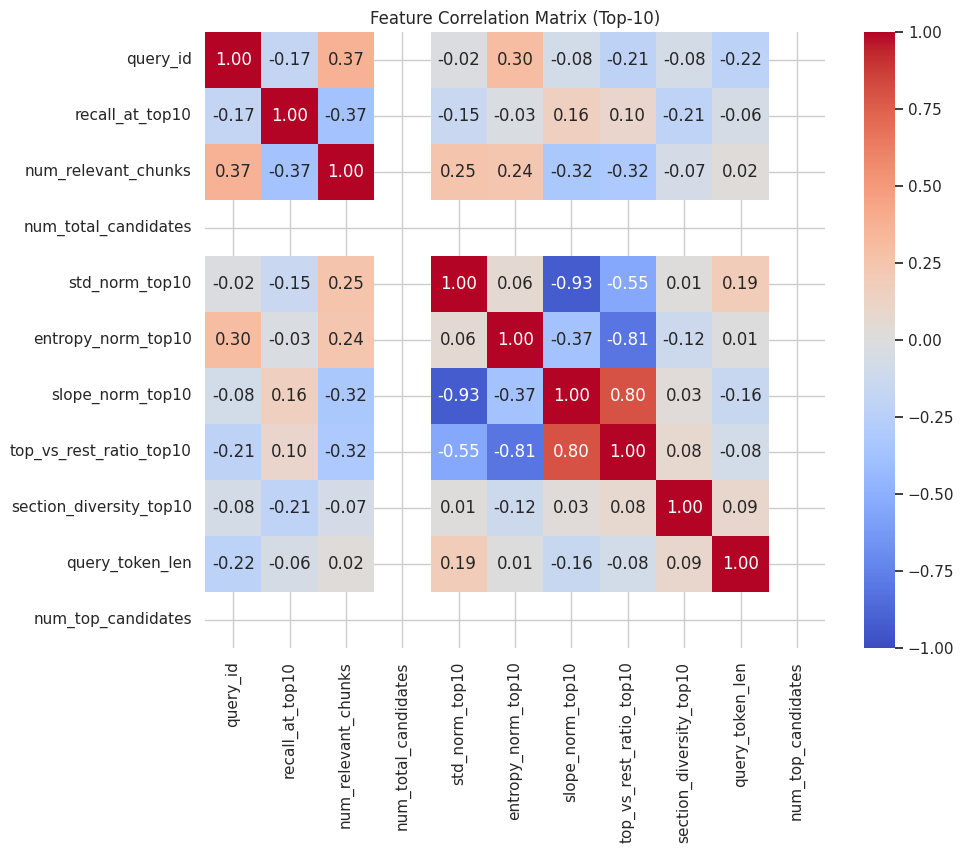

In [4]:
# Cell 4: Visualization Helper Function
def visualize_data(df, title_suffix):
    if df is None: return

    # Identify label column (usually 'recall' or similar, assuming 'label' or 'recall@k')
    # Based on prompt, looking for recall columns. Let's assume 'label' is the target.
    target_col = [c for c in df.columns if 'recall' in c.lower() or 'label' in c.lower()][0]
    print(f"Identified target column: {target_col}")

    # 1. Label Distribution
    plt.figure(figsize=(8, 4))
    sns.histplot(df[target_col], bins=20, kde=True)
    plt.title(f"Label Distribution ({title_suffix})")
    plt.xlabel("Recall / Confidence Score")
    plt.show()

    # 2. Correlation Matrix
    # Select numeric columns only
    numeric_df = df.select_dtypes(include=[np.number])
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
    plt.title(f"Feature Correlation Matrix ({title_suffix})")
    plt.show()



print("Visualizing Top-10 Data:")
visualize_data(df_10, "Top-10")

In [5]:
# Cell 7: Custom Beta Regression Model Class
class BetaModel(GenericLikelihoodModel):
    """
    Custom Beta Regression using statsmodels.

    Link functions:
    - Mean (mu): Logit (Sigmoid) -> maps (-inf, inf) to (0, 1)
    - Precision (phi): Log -> maps (-inf, inf) to (0, inf)

    The params vector contains coefficients for mu [beta] and one intercept for phi [gamma].
    """
    def __init__(self, endog, exog, **kwargs):
        super(BetaModel, self).__init__(endog, exog, **kwargs)

        # FIX 1: Account for the extra parameter (phi) to match statsmodels expectations
        self.k_extra = 1

        # FIX 2: Explicitly set nparams
        # nparams = predictors (exog columns) + k_extra (1 for phi)
        self.nparams = self.exog.shape[1] + self.k_extra

        # FIX 3: Update degrees of freedom for residuals to silence warnings
        self.df_resid = self.endog.shape[0] - self.nparams

    def nloglikeobs(self, params):
        # Split params: last element is for precision (phi), rest are for mean (mu)
        beta_params = params[:-1]
        gamma_param = params[-1]

        # Calculate mu (mean) = sigmoid(X * beta)
        exog_vector = self.exog
        mu_linear = np.dot(exog_vector, beta_params)
        mu = expit(mu_linear)

        # Calculate phi (precision) = exp(gamma)
        phi = np.exp(gamma_param)

        # Convert mu/phi to alpha/beta parameters of the Beta distribution
        # alpha = mu * phi
        # beta = (1 - mu) * phi
        alpha_p = mu * phi
        beta_p = (1 - mu) * phi

        # Calculate negative log-likelihood
        y = self.endog

        # Log PDF of Beta distribution
        ll = beta.logpdf(y, alpha_p, beta_p)
        return -ll

    def fit(self, start_params=None, maxiter=10000, maxfun=5000, **kwargs):
        if start_params is None:
            # Initialize: OLS for betas (zeros), 2.0 for phi (start precision approx 7.4)
            start_params = np.append(np.zeros(self.exog.shape[1]), 2.0)

        return super(BetaModel, self).fit(start_params=start_params,
                                          maxiter=maxiter, maxfun=maxfun, **kwargs)

    def predict(self, exog, params=None):
        # Ensure params are provided.
        if params is None:
            if hasattr(self, 'params'):
                params = self.params
            else:
                raise ValueError("Parameters must be passed to predict for GenericLikelihoodModel")

        beta_params = params[:-1]
        mu = expit(np.dot(exog, beta_params))
        return mu

In [11]:
# Cell 8: Training Pipeline Function (Updated)
def train_and_evaluate(df, name, selected_features=None):
    if df is None: return

    print(f"\n{'='*20}\nRunning Experiments for: {name}\n{'='*20}")

    # 1. Prepare Data
    # Infer target
    target_col = [c for c in df.columns if 'recall' in c.lower() or 'label' in c.lower()][0]

    # Select Features
    if selected_features is not None:
        print(f"Using Manually Selected Features: {selected_features}")
        feature_cols = selected_features
    else:
        # Default: Use all numeric features excluding ID and leakage columns
        feature_cols = [c for c in df.columns if c != target_col and df[c].dtype in [np.float64, np.int64]]
        feature_cols = [c for c in feature_cols if 'id' not in c.lower() and c != 'num_relevant_chunks']
        print(f"Using All Available Features: {feature_cols}")

    print(f"Target: {target_col}")

    X = df[feature_cols].values
    y = df[target_col].values

    # Clip labels for Beta Regression (must be strictly in (0, 1))
    # Squeeze 0 and 1 slightly inwards: y' = (y * (n-1) + 0.5) / n
    n = len(y)
    y_beta = (y * (n - 1) + 0.5) / n

    # Split
    X_train, X_test, y_train, y_test, y_train_beta, y_test_beta = train_test_split(
        X, y, y_beta, test_size=0.2, random_state=42
    )

    # Standardize Features
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    # --- Experiment A: Ridge Regression (Baseline) ---
    print("\n--- Model A: Ridge Regression ---")
    ridge = RidgeCV(alphas=[0.1, 1.0, 10.0])
    ridge.fit(X_train_sc, y_train)
    y_pred_ridge = ridge.predict(X_test_sc)

    mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
    rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    r2_ridge = r2_score(y_test, y_pred_ridge)

    print(f"Ridge MAE: {mae_ridge:.4f}")
    print(f"Ridge RMSE: {rmse_ridge:.4f}")
    print(f"Ridge R2: {r2_ridge:.4f}")

    # --- Experiment B: Custom Beta Regression ---
    print("\n--- Model B: Custom Beta Regression ---")
    # Add intercept column for statsmodels
    X_train_sm = sm.add_constant(X_train_sc)
    X_test_sm = sm.add_constant(X_test_sc)

    y_pred_beta = None # Initialize variable for plotting check

    try:
        model_beta = BetaModel(y_train_beta, X_train_sm)
        res_beta = model_beta.fit(disp=False)
        print(res_beta.summary())

        # Pass the fitted parameters (res_beta.params) to the predict function
        y_pred_beta = model_beta.predict(X_test_sm, params=res_beta.params)

        # Estimate precision phi from the last parameter
        est_phi = np.exp(res_beta.params[-1])
        print(f"\nEstimated Precision (phi): {est_phi:.4f}")

        mae_beta = mean_absolute_error(y_test, y_pred_beta)
        rmse_beta = np.sqrt(mean_squared_error(y_test, y_pred_beta))
        r2_beta = r2_score(y_test, y_pred_beta)

        print(f"Beta MAE: {mae_beta:.4f}")
        print(f"Beta RMSE: {rmse_beta:.4f}")
        print(f"Beta R2: {r2_beta:.4f}")

    except Exception as e:
        print(f"Beta Regression failed to converge or run: {e}")
        import traceback
        traceback.print_exc()

    # --- Plotting Actual vs Predicted ---
    print("\n--- Plotting Results ---")
    plt.figure(figsize=(14, 6))

    # Plot Ridge
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred_ridge, alpha=0.5, color='blue', label='Predictions')
    plt.plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect Fit')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('Actual Recall')
    plt.ylabel('Predicted Recall')
    plt.title(f'Ridge Regression: Actual vs Predicted\n(RMSE: {rmse_ridge:.4f})')
    plt.legend()

    # Plot Beta
    plt.subplot(1, 2, 2)
    if y_pred_beta is not None:
        plt.scatter(y_test, y_pred_beta, alpha=0.5, color='green', label='Predictions')
        plt.title(f'Beta Regression: Actual vs Predicted\n(RMSE: {rmse_beta:.4f})')
    else:
        plt.text(0.5, 0.5, 'Beta Model Failed', ha='center', va='center')
        plt.title('Beta Regression: Failed')

    plt.plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect Fit')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('Actual Recall')
    plt.ylabel('Predicted Recall')
    plt.legend()

    plt.suptitle(f'Model Performance Comparison - {name}', fontsize=16)
    plt.tight_layout()
    plt.show()


Running Experiments for: Dataset Top-10
Target: recall_at_top10
Features: ['std_norm_top10', 'entropy_norm_top10', 'slope_norm_top10', 'top_vs_rest_ratio_top10', 'section_diversity_top10', 'query_token_len']

--- Model A: Ridge Regression ---
Ridge MAE: 0.2821
Ridge RMSE: 0.3317
Ridge R2: 0.0852

--- Model B: Custom Beta Regression ---
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 74.948
Model:                      BetaModel   AIC:                            -133.9
Method:            Maximum Likelihood   BIC:                            -114.2
Date:                Tue, 25 Nov 2025                                         
Time:                        18:07:11                                         
No. Observations:                  87                                         
Df Residuals:                      79                                         
Df Model:                    

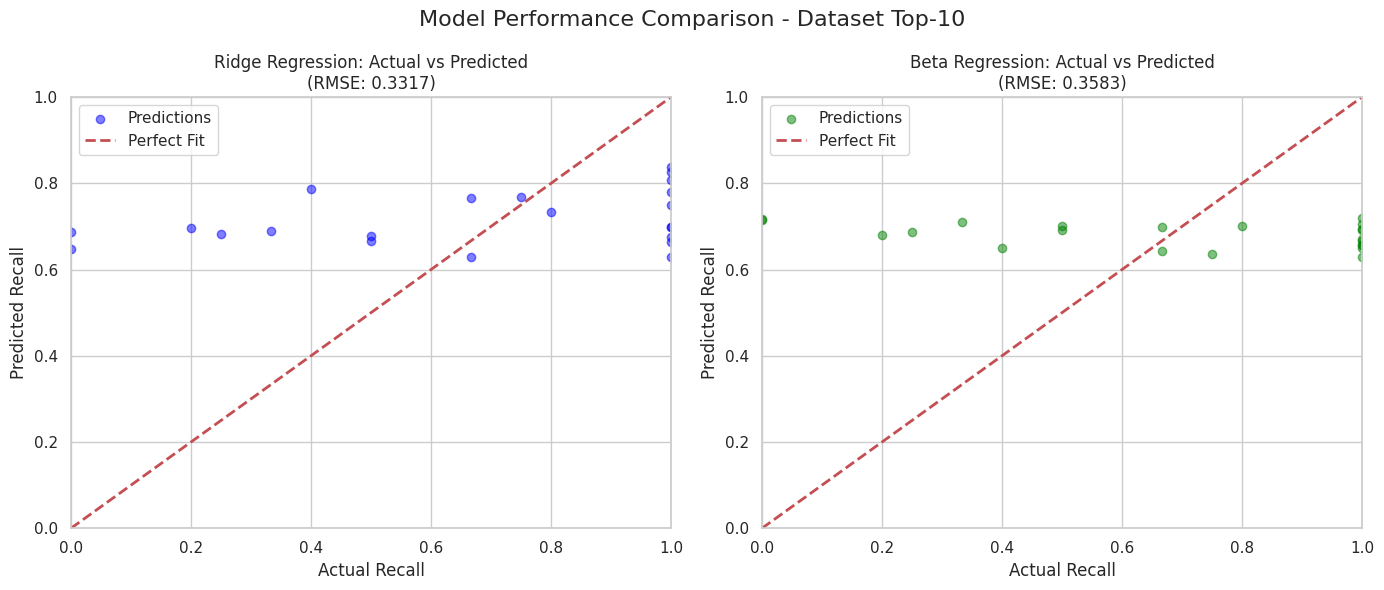

In [7]:
train_and_evaluate(df_10, "Dataset Top-10")


In [9]:
# Cell 11: Stepwise Regression Analysis
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

def perform_stepwise_analysis(df, name):
    if df is None: return

    print(f"\n{'='*20}\nStepwise Feature Selection: {name}\n{'='*20}")

    # 1. Prepare Data
    target_col = [c for c in df.columns if 'recall' in c.lower() or 'label' in c.lower()][0]
    feature_cols = [c for c in df.columns if c != target_col and df[c].dtype in [np.float64, np.int64]]

    # exclude IDs and num_relevant_chunks
    # CHANGED: Added 'num_relevant_chunks' to exclusion list here as well
    feature_cols = [c for c in feature_cols if 'id' not in c.lower() and c != 'num_relevant_chunks']

    X = df[feature_cols].values
    y = df[target_col].values

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Base estimator for selection
    lr = LinearRegression()

    # 2. Forward Selection
    # We ask it to select, for example, the top 50% of features, or use 'auto' with a scoring criteria
    # Here we select 'auto' via n_features_to_select='auto' (available in newer sklearn)
    # or specific number. Let's try finding the best 3 features first to see what's dominant.
    print(f"Total features available ({len(feature_cols)}): {feature_cols}")

    # --- Forward Selection ---
    sfs_forward = SequentialFeatureSelector(lr, n_features_to_select=3, direction='forward', cv=5)
    sfs_forward.fit(X_scaled, y)
    selected_indices_fwd = sfs_forward.get_support()
    selected_features_fwd = [f for f, s in zip(feature_cols, selected_indices_fwd) if s]

    print(f"\n[Forward Selection] Top 3 Features:")
    print(f" -> {selected_features_fwd}")

    # --- Backward Selection ---
    sfs_backward = SequentialFeatureSelector(lr, n_features_to_select=3, direction='backward', cv=5)
    sfs_backward.fit(X_scaled, y)
    selected_indices_bwd = sfs_backward.get_support()
    selected_features_bwd = [f for f, s in zip(feature_cols, selected_indices_bwd) if s]

    print(f"\n[Backward Selection] Top 3 Features:")
    print(f" -> {selected_features_bwd}")

# Run Analysis
perform_stepwise_analysis(df_10, "Dataset Top-10")
if df_100 is not None:
    perform_stepwise_analysis(df_100, "Dataset Top-100")


Stepwise Feature Selection: Dataset Top-10
Total features available (6): ['std_norm_top10', 'entropy_norm_top10', 'slope_norm_top10', 'top_vs_rest_ratio_top10', 'section_diversity_top10', 'query_token_len']

[Forward Selection] Top 3 Features:
 -> ['slope_norm_top10', 'top_vs_rest_ratio_top10', 'section_diversity_top10']

[Backward Selection] Top 3 Features:
 -> ['slope_norm_top10', 'top_vs_rest_ratio_top10', 'section_diversity_top10']

Stepwise Feature Selection: Dataset Top-100
Total features available (6): ['std_norm_top100', 'entropy_norm_top100', 'slope_norm_top100', 'top_vs_rest_ratio_top100', 'section_diversity_top100', 'query_token_len']

[Forward Selection] Top 3 Features:
 -> ['std_norm_top100', 'top_vs_rest_ratio_top100', 'section_diversity_top100']

[Backward Selection] Top 3 Features:
 -> ['entropy_norm_top100', 'slope_norm_top100', 'top_vs_rest_ratio_top100']


Running Refined Training for Top-10...

Running Experiments for: Dataset Top-10 (Top 3 Features)
Using Manually Selected Features: ['slope_norm_top10', 'top_vs_rest_ratio_top10', 'section_diversity_top10']
Target: recall_at_top10

--- Model A: Ridge Regression ---
Ridge MAE: 0.2812
Ridge RMSE: 0.3270
Ridge R2: 0.1111

--- Model B: Custom Beta Regression ---
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 77.483
Model:                      BetaModel   AIC:                            -145.0
Method:            Maximum Likelihood   BIC:                            -132.6
Date:                Tue, 25 Nov 2025                                         
Time:                        18:13:24                                         
No. Observations:                  87                                         
Df Residuals:                      82                                         
Df Model

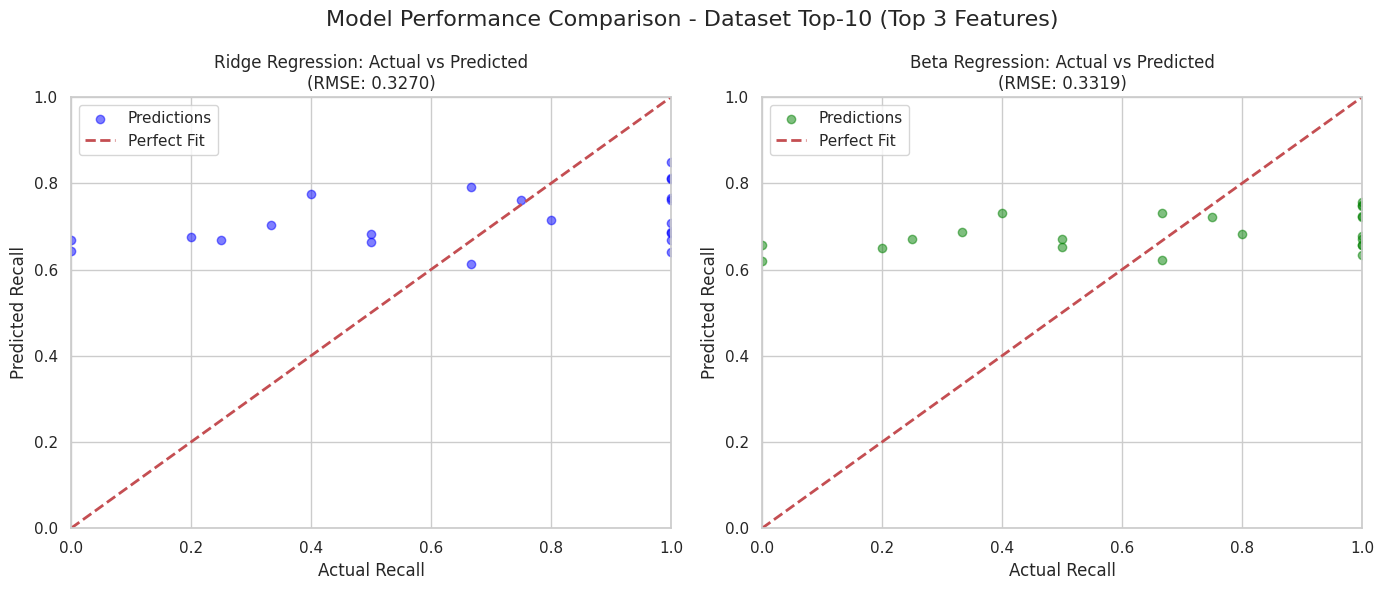


Running Refined Training for Top-100...

Running Experiments for: Dataset Top-100 (Top 3 Features)
Using Manually Selected Features: ['std_norm_top100', 'top_vs_rest_ratio_top100', 'section_diversity_top100']
Target: recall_at_top100

--- Model A: Ridge Regression ---
Ridge MAE: 0.0513
Ridge RMSE: 0.0557
Ridge R2: -0.7860

--- Model B: Custom Beta Regression ---
                              BetaModel Results                               
Dep. Variable:                      y   Log-Likelihood:                 198.91
Model:                      BetaModel   AIC:                            -387.8
Method:            Maximum Likelihood   BIC:                            -375.5
Date:                Tue, 25 Nov 2025                                         
Time:                        18:13:26                                         
No. Observations:                  87                                         
Df Residuals:                      82                                         
Df

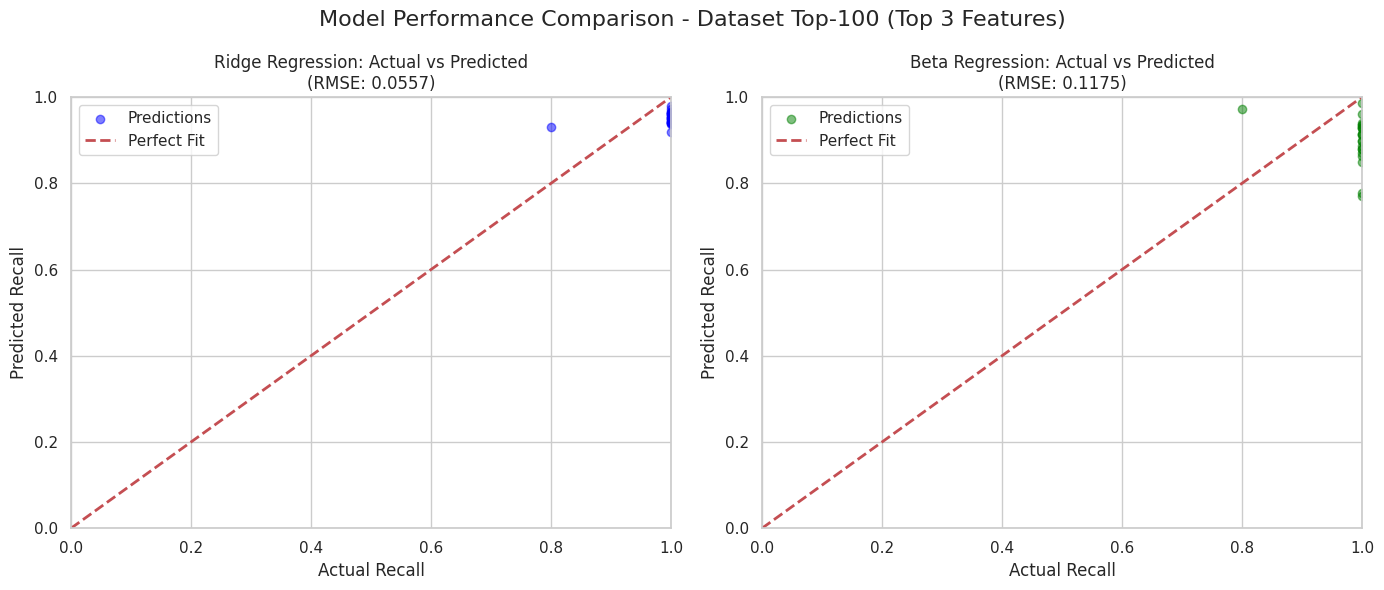

In [12]:
# Cell 12: Train with Stepwise Selected Features
# Top 3 features identified by Stepwise Regression (Forward/Backward agreed for Top-10)
features_top10 = [
    'slope_norm_top10',
    'top_vs_rest_ratio_top10',
    'section_diversity_top10'
]

print("Running Refined Training for Top-10...")
train_and_evaluate(df_10, "Dataset Top-10 (Top 3 Features)", selected_features=features_top10)

if df_100 is not None:
    # Top 3 features identified by Stepwise Regression (Forward Selection for Top-100)
    features_top100 = [
        'std_norm_top100',
        'top_vs_rest_ratio_top100',
        'section_diversity_top100'
    ]
    print("\nRunning Refined Training for Top-100...")
    train_and_evaluate(df_100, "Dataset Top-100 (Top 3 Features)", selected_features=features_top100)